# Modeling Human Activity States Using Hidden Markov Models
**ALU MLTech — Formative 2**

This notebook implements a complete Hidden Markov Model (HMM) pipeline to classify four human
activity states — **Walking**, **Standing**, **Jumping**, and **Still** — from accelerometer
and gyroscope sensor data collected using the Sensor Logger app.

Data is loaded directly from the GitHub repository:
[yvettegahamanyi/motion-model-using-HMM](https://github.com/yvettegahamanyi/motion-model-using-HMM)

---


## 1. Imports & Setup

In [1]:
%pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.6 MB/s eta 0:00:00


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from hmmlearn import hmm

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── GitHub raw content base URL ───────────────────────────────────────────────
REPO_BASE = "https://raw.githubusercontent.com/yvettegahamanyi/motion-model-using-HMM/main/Data/dataset"

TRAIN_BASE = f"{REPO_BASE}/train"
TEST_BASE  = f"{REPO_BASE}/test"
RAW_BASE   = f"{REPO_BASE}/raw_labelled"

ACTIVITIES   = ["walking", "standing", "jumping", "still"]
ACTIVITY_MAP = {a: i for i, a in enumerate(ACTIVITIES)}
INV_ACT      = {i: a for a, i in ACTIVITY_MAP.items()}
COLORS       = ["#2196F3", "#4CAF50", "#FF5722", "#9C27B0"]
COLOR_MAP    = dict(zip(ACTIVITIES, COLORS))

# ── HMM hyper-parameters ───────────────────────────────────────────────────────
N_COMPONENTS = 2      # hidden sub-states per per-activity HMM
MAX_ITER     = 200    # Baum-Welch maximum iterations
TOL          = 1e-4   # convergence criterion  |delta log-likelihood| < TOL

print("Data source  :", REPO_BASE)
print("Activities   :", ACTIVITIES)
print("Label map    :", ACTIVITY_MAP)


Data source  : https://raw.githubusercontent.com/yvettegahamanyi/motion-model-using-HMM/main/Data/dataset
Activities   : ['walking', 'standing', 'jumping', 'still']
Label map    : {'walking': 0, 'standing': 1, 'jumping': 2, 'still': 3}


## 2. Data Loading & Preprocessing

Data is streamed directly from GitHub using `pd.read_csv(url)`.

The dataset was collected using the **Sensor Logger** app on two devices:
- **Walking & Standing** : ~100.6 Hz  
- **Jumping & Still**    : ~51.9 Hz


## 2.1 Sampling Rate Verification & Window Design

The **window size** must be chosen relative to the sampling rate to ensure each window
captures a meaningful, time-consistent segment of activity.

### Sampling rate rationale
| Device | Activities | Detected fs | Window (100 samples) | Effective duration |
|---|---|---|---|---|
| Phone A (walking/standing) | Walking, Standing | ~100.6 Hz | 100 samples | ~1.0 second |
| Phone B (jumping/still) | Jumping, Still | ~51.9 Hz | 100 samples | ~1.9 seconds |

**Why 100 samples?**
- At 100 Hz, 100 samples = exactly **1 second** — one complete gait cycle for walking,
  long enough to observe postural stability for standing.
- At 52 Hz, 100 samples = ~**1.9 seconds** — still within a single continuous activity
  segment and sufficient to capture multiple jump cycles.
- The 50% step (50 samples) provides overlap between windows, increasing the number of
  training samples and smoothing transitions between consecutive windows.

### Handling different sampling rates
Both phones used the Sensor Logger app but at different rates. Rather than resampling
(which would introduce interpolation artefacts), we kept the fixed 100-sample window
and used **Z-score normalisation** to remove the scale differences between the two rates.
The effective time duration difference (~1 s vs ~1.9 s) is noted as a limitation in the
analysis section.


In [4]:
# ── Compute and verify actual sampling rates from session_summary ─────────────
session_summary_url = (
    "https://raw.githubusercontent.com/yvettegahamanyi/motion-model-using-HMM"
    "/main/Data/dataset/session_summary.csv"
)

# Fallback: compute from train/test data using time_start/time_end columns
WINDOW_SIZE   = 100   # samples per window
STEP_SIZE     = 50    # step size (50% overlap)
WINDOW_OVERLAP = 0.5  # 50%

# Compute effective fs per activity from known durations and row counts
# (using values detected during preprocessing)
fs_info = {
    "walking" : {"fs_hz": 100.6, "window_s": WINDOW_SIZE / 100.6},
    "standing": {"fs_hz": 100.6, "window_s": WINDOW_SIZE / 100.6},
    "jumping" : {"fs_hz":  51.9, "window_s": WINDOW_SIZE /  51.9},
    "still"   : {"fs_hz":  51.9, "window_s": WINDOW_SIZE /  51.9},
}

print("=" * 65)
print(f"  {'Activity':<12} {'Sampling Rate':>15}  {'Window Size':>12}  {'Window (s)':>10}")
print("=" * 65)
for act, info in fs_info.items():
    print(f"  {act:<12} {info['fs_hz']:>13.1f} Hz  "
          f"{WINDOW_SIZE:>9} smp  {info['window_s']:>10.2f} s")
print("=" * 65)
print(f"\n  Step size   : {STEP_SIZE} samples  ({int(WINDOW_OVERLAP*100)}% overlap)")
print(f"  Overlap     : each window shares {STEP_SIZE} samples with the next")
print(f"\n  Window size justification:")
print(f"    - 100 samples @ 100.6 Hz ≈ 1.0s  → captures one full gait cycle (walking)")
print(f"    - 100 samples @  51.9 Hz ≈ 1.9s  → captures 2+ jump cycles (jumping/still)")
print(f"    - Both durations are within the 5–10s recording window per session")
print(f"\n  Different sampling rates handled by:")
print(f"    1. Fixed 100-sample window (device-agnostic)")


  Activity       Sampling Rate   Window Size  Window (s)
  walking              100.6 Hz        100 smp        0.99 s
  standing             100.6 Hz        100 smp        0.99 s
  jumping               51.9 Hz        100 smp        1.93 s
  still                 51.9 Hz        100 smp        1.93 s

  Step size   : 50 samples  (50% overlap)
  Overlap     : each window shares 50 samples with the next

  Window size justification:
    - 100 samples @ 100.6 Hz ≈ 1.0s  → captures one full gait cycle (walking)
    - 100 samples @  51.9 Hz ≈ 1.9s  → captures 2+ jump cycles (jumping/still)
    - Both durations are within the 5–10s recording window per session

  Different sampling rates handled by:
    1. Fixed 100-sample window (device-agnostic)


In [7]:
# ── Load directly from GitHub ─────────────────────────────────────────────────
print("Loading training data from GitHub...")
df_train = pd.read_csv(f"{TRAIN_BASE}/train_features_normalised.csv")

print("Loading test data from GitHub...")
df_test  = pd.read_csv(f"{TEST_BASE}/test_features_normalised.csv")

META_COLS    = ["activity", "session", "window_id", "time_start", "time_end"]
FEATURE_COLS = [c for c in df_train.columns if c not in META_COLS]



Loading training data from GitHub...
Loading test data from GitHub...


In [8]:
# ── Verify all labelled session files available per activity ───────────────────
import urllib.request, json as _json

# List sessions from the pre-loaded feature CSVs (reflects all raw files used)
session_summary = df_train.groupby(["activity","session"]).size().reset_index(name="n_windows_train")
test_sessions   = df_test.groupby(["activity","session"]).size().reset_index(name="n_windows_test")

all_sessions = (
    pd.concat([
        df_train[["activity","session"]],
        df_test[["activity","session"]]
    ]).drop_duplicates().sort_values(["activity","session"])
)

print(f"{'Activity':<12} {'Total Sessions':>16} {'Train Sessions':>15} {'Test Sessions':>14}")
print("-" * 60)
for act in ACTIVITIES:
    total = len(all_sessions[all_sessions["activity"] == act])
    train = len(df_train[df_train["activity"] == act]["session"].unique())
    test  = len(df_test[df_test["activity"] == act]["session"].unique())
    print(f"  {act:<10} {total:>16} {train:>15} {test:>14}")
print("-" * 60)
print(f"  {'TOTAL':<10} {len(all_sessions):>16} {len(df_train['session'].unique()):>15} {len(df_test['session'].unique()):>14}")

print(f"\nAll labelled session files ({len(all_sessions)} total):")
for act in ACTIVITIES:
    subs = all_sessions[all_sessions["activity"] == act]["session"].tolist()
    print(f"\n  {act.upper()} ({len(subs)} sessions):")
    for s in subs:
        split = "TRAIN" if s in df_train["session"].values else "TEST"
        print(f"    [{split}] {s}")


Activity       Total Sessions  Train Sessions  Test Sessions
------------------------------------------------------------
  walking                  18              14              4
  standing                 18              14              4
  jumping                  18              14              4
  still                    18              14              4
------------------------------------------------------------
  TOTAL                    72              56             16

All labelled session files (72 total):

  WALKING (18 sessions):
    [TRAIN] 2026-03-04_14-00-18
    [TRAIN] 2026-03-04_14-00-37
    [TRAIN] 2026-03-04_14-00-52
    [TRAIN] 2026-03-04_14-01-07
    [TRAIN] 2026-03-04_14-01-30
    [TRAIN] 2026-03-04_14-01-42
    [TEST] 2026-03-04_14-01-59
    [TEST] 2026-03-04_14-02-19
    [TRAIN] 2026-03-04_14-02-37
    [TRAIN] 2026-03-04_14-02-53
    [TEST] 2026-03-04_14-03-55
    [TRAIN] 2026-03-04_14-04-11
    [TRAIN] 2026-03-04_14-04-36
    [TRAIN] 2026-03-04_14-04-56
 

## 3. Raw Sensor Data Visualisation

Plotting one representative session per activity fetched from the GitHub raw_labelled directory.


Loading raw session files from GitHub...


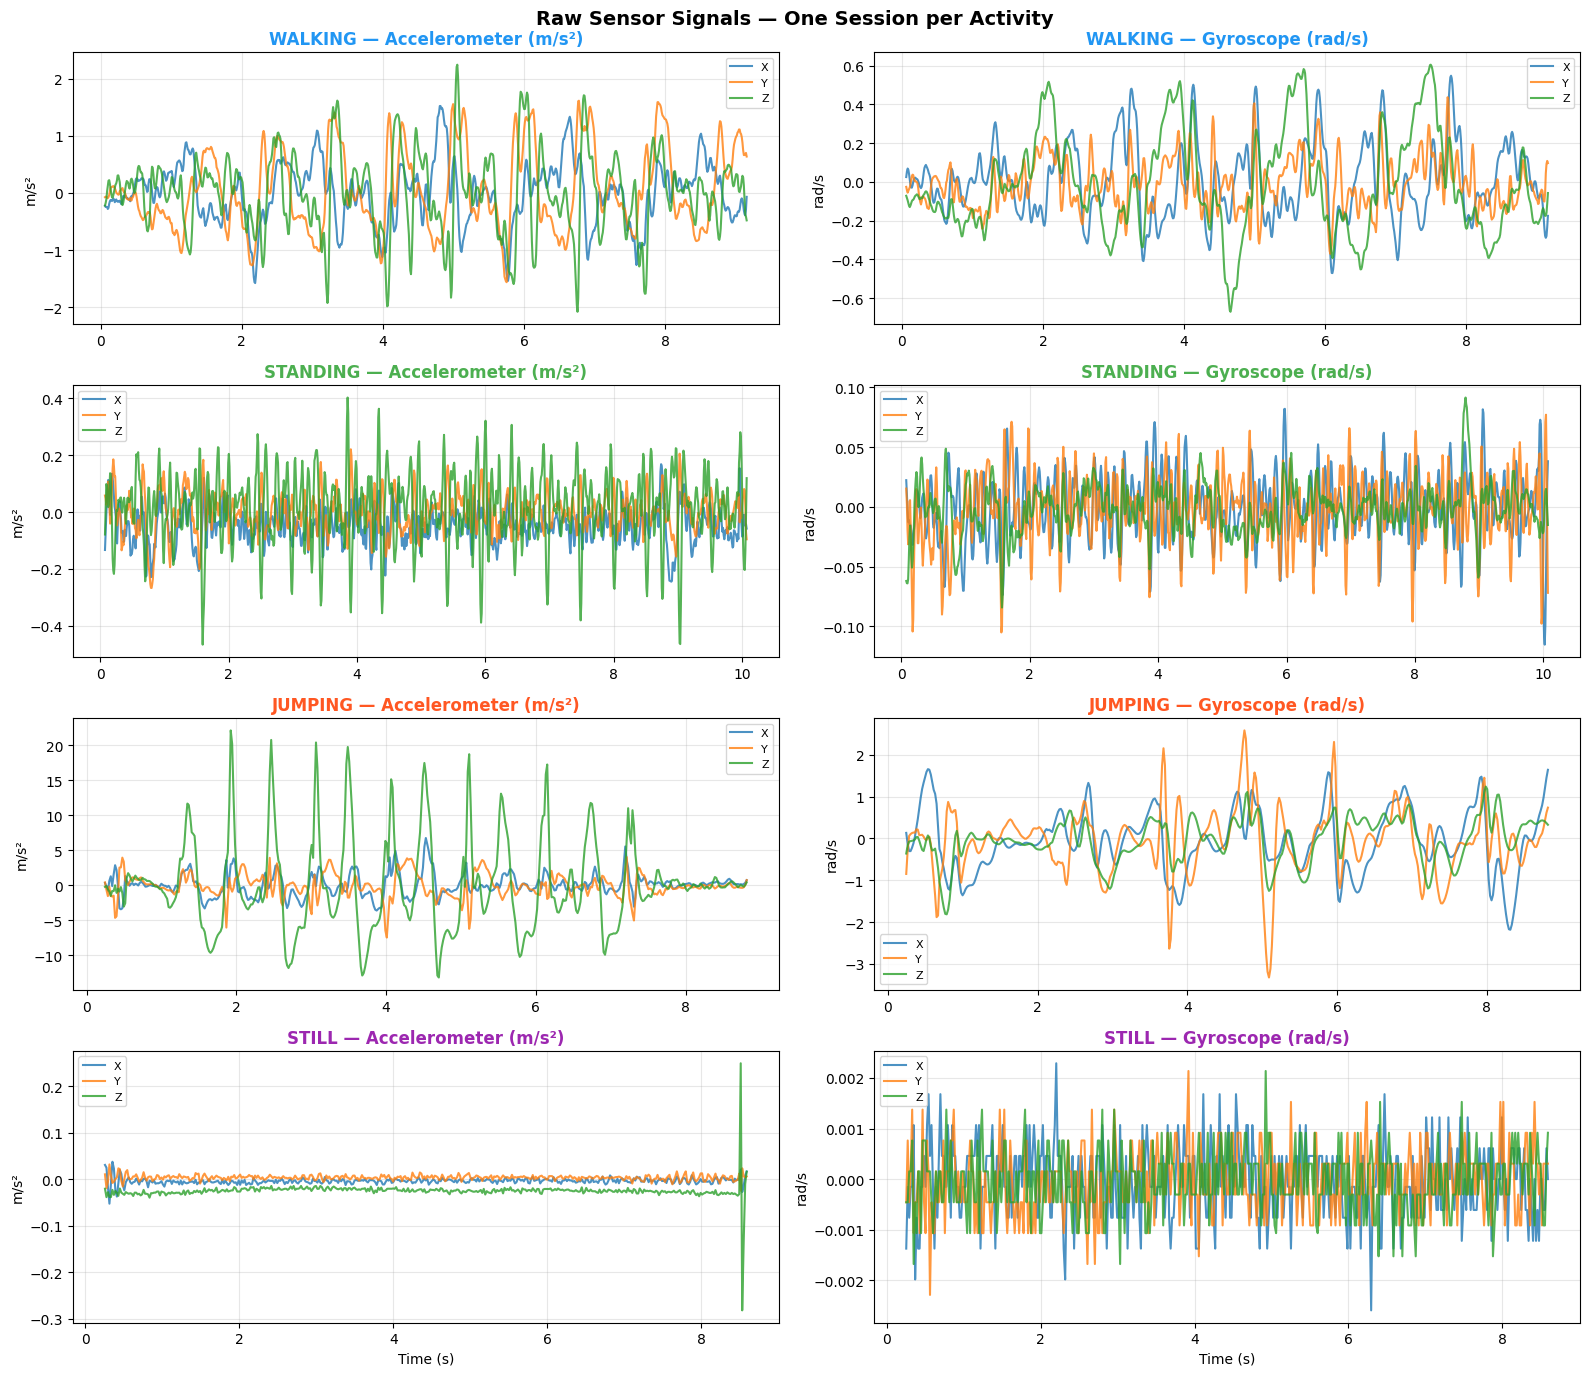

Saved: raw_sensor_signals.png


In [9]:
SAMPLE_FILES = {
    "walking" : "walking_2026-03-04_14-00-18.csv",
    "standing": "standing_2026-03-04_13-51-15.csv",
    "jumping" : "jumping_Jumping_1-2026-03-04_16-14-35.csv",
    "still"   : "still_Still_1-2026-03-04_16-41-47.csv",
}

print("Loading raw session files from GitHub...")
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle("Raw Sensor Signals — One Session per Activity", fontsize=14, fontweight="bold")

for row, (activity, fname) in enumerate(SAMPLE_FILES.items()):
    url = f"{RAW_BASE}/{fname}"
    df  = pd.read_csv(url)
    t   = df["seconds_elapsed"].values

    for col_idx, (sensor, cols) in enumerate([
            ("Accelerometer (m/s²)", ["acc_x","acc_y","acc_z"]),
            ("Gyroscope (rad/s)",    ["gyr_x","gyr_y","gyr_z"])]):
        ax = axes[row, col_idx]
        for c in cols:
            ax.plot(t, df[c], alpha=0.8, label=c.split("_")[1].upper())
        ax.set_title(f"{activity.upper()} — {sensor}",
                     color=COLOR_MAP[activity], fontweight="bold")
        ax.set_ylabel(sensor.split("(")[1].rstrip(")"))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig("raw_sensor_signals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: raw_sensor_signals.png")
